In [ ]:
# Step 0: clean slate
!rm -rf /content/data /content/models /content/kaggle ~/.kaggle
!mkdir -p /content/data /content/models
import os, sys, json, pathlib, shutil, random


In [ ]:
from google.colab import files
print("Select kaggle.json"); up = files.upload()

!pip -q install kaggle
import os; os.makedirs("/root/.kaggle", exist_ok=True)
open("/root/.kaggle/kaggle.json","wb").write(up["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

DATASET = "owner/dataset-name"   # <-- replace with the exact Kaggle slug
!mkdir -p /content/data
!kaggle datasets download -d {DATASET} -p /content/data
!unzip -q /content/data/*.zip -d /content/data



Select kaggle.json


Saving kaggle.json to kaggle.json
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/owner/dataset-name
unzip:  cannot find or open /content/data/*.zip, /content/data/*.zip.zip or /content/data/*.zip.ZIP.

No zipfiles found.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.25G/1.25G [00:14<00:00, 89.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1


In [ ]:
# If you lost 'path', re-run your kagglehub cell to get it again:
# import kagglehub
# path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("DATASET ROOT:", path)

from pathlib import Path
root = Path(path)

# This dataset already has Train / Validation / Test folders (case-insensitive).
def find_split_dir(root, name_options):
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in name_options:
            return p
    return None

train_dir = find_split_dir(root, {"train","training"})
val_dir   = find_split_dir(root, {"valid","validation","val"})
test_dir  = find_split_dir(root, {"test","testing"})

print("Train:", train_dir)
print("Val  :", val_dir)
print("Test :", test_dir)
assert train_dir and val_dir and test_dir, "Train/Val/Test folders not found."


DATASET ROOT: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1
Train: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Train
Val  : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Validation
Test : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Test


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 123
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED)
val_ds   = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,   image_size=IMG_SIZE, batch_size=BATCH, shuffle=False, seed=SEED)
test_ds  = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,  image_size=IMG_SIZE, batch_size=BATCH, shuffle=False, seed=SEED)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Normalize + Augment
def prep(ds, training=False):
    ds = ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.1),
            layers.GaussianNoise(0.01),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds_p = prep(train_ds, training=True)
val_ds_p   = prep(val_ds)
test_ds_p  = prep(test_ds)


Found 1322 files belonging to 1 classes.
Found 60 files belonging to 1 classes.
Found 150 files belonging to 1 classes.
Classes: ['Train']


**Model 1 — Small CNN (from scratch)**

In [ ]:
# 0) (optional) clear old models/datasets from memory
import gc, tensorflow as tf
tf.keras.backend.clear_session(); gc.collect();

# 1) Use the kagglehub path you already have
# print(path)  # e.g., /root/.cache/kagglehub/datasets/.../plant-disease-recognition-dataset/versions/1
from pathlib import Path
root = Path(path)

# 2) Point to the correct split directories (case-insensitive)
train_dir = (root/'Train') if (root/'Train').exists() else (root/'train')
val_dir   = (root/'Validation') if (root/'Validation').exists() else (root/'valid')
test_dir  = (root/'Test') if (root/'Test').exists() else (root/'test')

print("train_dir:", train_dir)
print("val_dir  :", val_dir)
print("test_dir :", test_dir)

# 3) Quick sanity: each of these MUST contain >=2 class subfolders
print("train classes:", [p.name for p in train_dir.iterdir() if p.is_dir()][:10])


train_dir: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Train
val_dir  : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Validation
test_dir : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Test
train classes: ['Train']


In [ ]:
import kagglehub
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("DATASET ROOT:", path)


DATASET ROOT: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1


In [ ]:
from pathlib import Path

root = Path(path)

IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif"}

def contains_class_dirs(p: Path) -> bool:
    """True if p has >=2 immediate subdirs and each has images somewhere inside."""
    subs = [d for d in p.iterdir() if d.is_dir()]
    if len(subs) < 2:
        return False
    hits = 0
    for d in subs:
        if any(f.suffix.lower() in IMG_EXTS for f in d.rglob("*")):
            hits += 1
    return hits >= 2

def find_split(root: Path, names: set) -> Path:
    """Find a folder named like Train/Validation/Test anywhere under root,
       then descend until we reach the level that contains class dirs."""
    # 1) find the split folder by name (case-insensitive)
    cand = None
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in names:
            cand = p; break
    if cand is None:
        raise RuntimeError(f"Couldn't find any of {names} under {root}")

    # 2) if this folder doesn't yet contain the class dirs, go one level deeper
    # (handles nested structures like .../Split/Split/Healthy,...)
    cur = cand
    for _ in range(3):  # descend at most 3 levels just in case
        if contains_class_dirs(cur):
            return cur
        # if only one subdir, step into it; else break
        subs = [d for d in cur.iterdir() if d.is_dir()]
        if len(subs) == 1:
            cur = subs[0]
        else:
            break
    # final check
    if not contains_class_dirs(cur):
        raise RuntimeError(f"{cur} does not contain class folders directly.")
    return cur

train_dir = find_split(root, {"train","training"})
val_dir   = find_split(root, {"validation","valid","val"})
test_dir  = find_split(root, {"test","testing"})

print("train_dir:", train_dir)
print("val_dir  :", val_dir)
print("test_dir :", test_dir)

# Show the immediate class folders we will load
print("TRAIN classes:", sorted([d.name for d in train_dir.iterdir() if d.is_dir()]))
print("VAL   classes:", sorted([d.name for d in val_dir.iterdir() if d.is_dir()]))
print("TEST  classes:", sorted([d.name for d in test_dir.iterdir() if d.is_dir()]))


train_dir: /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Train/Train
val_dir  : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Validation/Validation
test_dir : /root/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1/Test/Test
TRAIN classes: ['Healthy', 'Powdery', 'Rust']
VAL   classes: ['Healthy', 'Powdery', 'Rust']
TEST  classes: ['Healthy', 'Powdery', 'Rust']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224,224); BATCH = 32; SEED = 123
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED)
val_ds   = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,   image_size=IMG_SIZE, batch_size=BATCH, shuffle=False, seed=SEED)
test_ds  = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,  image_size=IMG_SIZE, batch_size=BATCH, shuffle=False, seed=SEED)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names, "| num_classes:", num_classes)


Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.
Classes: ['Healthy', 'Powdery', 'Rust'] | num_classes: 3


In [ ]:
def prep(ds, training=False):
    ds = ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.1),
            layers.GaussianNoise(0.01),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds_p = prep(train_ds, training=True)
val_ds_p   = prep(val_ds)
test_ds_p  = prep(test_ds)


In [ ]:
def build_small_cnn(input_shape=IMG_SIZE+(3,), classes=num_classes):
    i = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(i)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    o = layers.Dense(classes, activation="softmax")(x)
    return keras.Model(i, o, name="SmallCNN")

model1 = build_small_cnn()
print("Output:", model1.output_shape, " (should be (None, num_classes))")

model1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

cb1 = [
    keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor="val_accuracy"),
    keras.callbacks.ModelCheckpoint("/content/models/model1_smallcnn.keras", save_best_only=True)
]

history1 = model1.fit(train_ds_p, validation_data=val_ds_p, epochs=5, callbacks=cb1)


Output: (None, 3)  (should be (None, num_classes))
Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 266s 6s/step - accuracy: 0.3680 - loss: 1.0941 - val_accuracy: 0.5000 - val_loss: 0.9980
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.5138 - loss: 0.9543 - val_accuracy: 0.4500 - val_loss: 1.0331
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.5722 - loss: 0.8605 - val_accuracy: 0.5833 - val_loss: 0.8212
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.5803 - loss: 0.8271 - val_accuracy: 0.6333 - val_loss: 0.8083
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.6262 - loss: 0.7868 - val_accuracy: 0.5833 - val_loss: 0.8187


**Model 2 — Transfer learning (feature extract → fine-tune)**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Stage 1: feature extractor (frozen base) ---
base = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet"
)
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE+(3,))
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model2 = keras.Model(inputs, outputs, name="MobileNetV2_transfer")

model2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

cb2 = [
    keras.callbacks.EarlyStopping(patience=3, monitor="val_accuracy", restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/models/model2_mnv2_stage1.keras", save_best_only=True)
]

history2 = model2.fit(
    train_ds, validation_data=val_ds, epochs=8, callbacks=cb2
)

# --- Stage 2: fine-tune last ~30 layers ---
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model2.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

cb3 = [
    keras.callbacks.EarlyStopping(patience=3, monitor="val_accuracy", restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/models/model2_mnv2_finetune.keras", save_best_only=True)
]

history2_ft = model2.fit(
    train_ds, validation_data=val_ds, epochs=8, callbacks=cb3
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.6356 - loss: 0.8114 - val_accuracy: 0.9500 - val_loss: 0.1891
Epoch 2/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.9472 - loss: 0.2051 - val_accuracy: 0.9667 - val_loss: 0.1246
Epoch 3/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9535 - loss: 0.1469 - val_accuracy: 0.9833 - val_loss: 0.1013
Epoch 4/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.9718 - loss: 0.1110 - val_accuracy: 0.9500 - val_loss: 0.0924
Epoch 5/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9730 - loss: 0.0965 - val_accuracy: 0.9833 - val_loss: 0.0798
Epoch 6/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9746 - loss: 0.0888 - val_accuracy: 0.9833 - val_loss: 0.0771
Epoch 1/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.9388 - loss: 0.1702 - val_accuracy: 0.9167 - val_loss: 0.1741
Epoch 2/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 211s 4s/step - accuracy: 0.9997 


SmallCNN — Test metrics
Accuracy: 0.6600 | Precision: 0.6695 | Recall: 0.6600 | F1: 0.6452

              precision    recall  f1-score   support

     Healthy       0.62      0.74      0.67        50
     Powdery       0.68      0.84      0.75        50
        Rust       0.71      0.40      0.51        50

    accuracy                           0.66       150
   macro avg       0.67      0.66      0.65       150
weighted avg       0.67      0.66      0.65       150



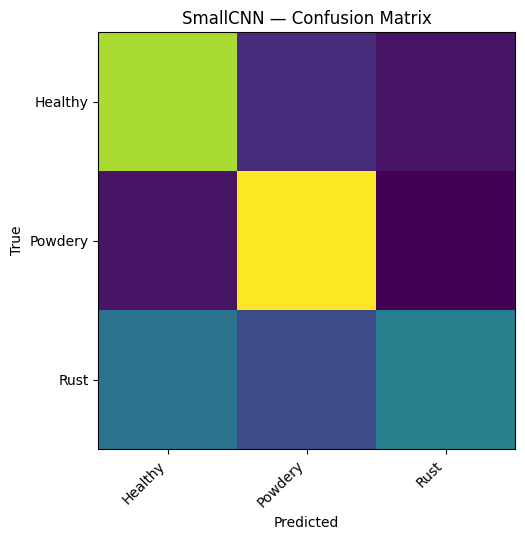


MobileNetV2 — Test metrics
Accuracy: 0.9333 | Precision: 0.9444 | Recall: 0.9333 | F1: 0.9339

              precision    recall  f1-score   support

     Healthy       0.83      1.00      0.91        50
     Powdery       1.00      0.84      0.91        50
        Rust       1.00      0.96      0.98        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



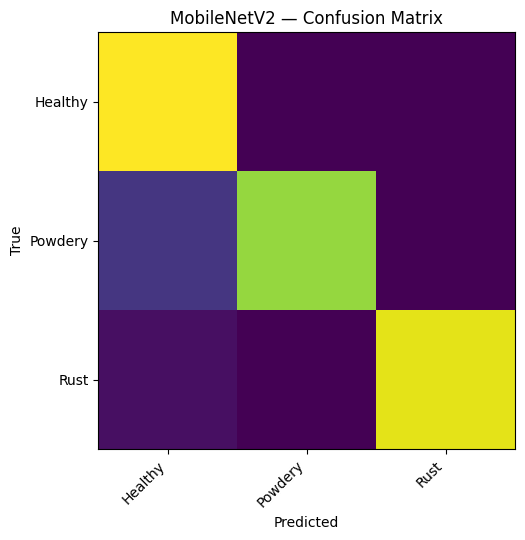

Artifacts saved in /content/models
M1: {'accuracy': np.float64(0.66), 'precision': 0.6694572452636969, 'recall': 0.66, 'f1': 0.645182595182595, 'cm_path': '/content/models/SmallCNN_cm.png'}
M2: {'accuracy': np.float64(0.9333333333333333), 'precision': 0.9444444444444445, 'recall': 0.9333333333333333, 'f1': 0.9339087413621576, 'cm_path': '/content/models/MobileNetV2_cm.png'}


In [ ]:
import numpy as np, json, os, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

os.makedirs("/content/models", exist_ok=True)

def evaluate_model(name, model, ds, class_names):
    y_true = np.concatenate([y.numpy() for _,y in ds])
    y_prob = model.predict(ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)

    acc = (y_pred == y_true).mean()
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    print(f"\n{name} — Test metrics")
    print(f"Accuracy: {acc:.4f} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(5.5,5.5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{name} — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    out = f"/content/models/{name.replace(' ','_')}_cm.png"
    plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
    return {"accuracy":acc, "precision":p, "recall":r, "f1":f1, "cm_path":out}

# SmallCNN was trained on normalized/augmented datasets -> evaluate on test_ds_p
m1 = evaluate_model("SmallCNN", model1, test_ds_p, class_names)
# MobileNetV2 uses its own preprocess inside the model -> evaluate on raw test_ds
m2 = evaluate_model("MobileNetV2", model2, test_ds, class_names)

# Save label map + final models
with open("/content/models/labels.json","w") as f:
    json.dump({i:c for i,c in enumerate(class_names)}, f, indent=2)

model1.save("/content/models/plant_smallcnn.keras")
model2.save("/content/models/plant_mobilenetv2.keras")

print("Artifacts saved in /content/models")
print("M1:", m1); print("M2:", m2)



MobileNetV2 — Test Accuracy=0.933  Precision=0.944  Recall=0.933  F1=0.934

              precision    recall  f1-score   support

     Healthy       0.83      1.00      0.91        50
     Powdery       1.00      0.84      0.91        50
        Rust       1.00      0.96      0.98        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



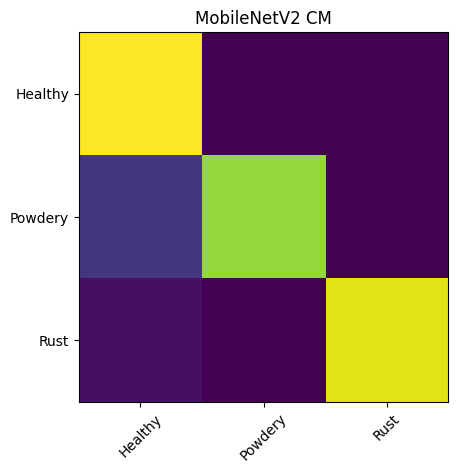

In [ ]:
# Run this if you haven’t yet (re-uses your earlier function if defined)
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

def evaluate_model(name, model, ds, class_names):
    y_true = np.concatenate([y.numpy() for _,y in ds])
    y_prob = model.predict(ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    acc = (y_pred == y_true).mean()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{name} — Test Accuracy={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.imshow(cm); plt.title(name+" CM"); plt.xticks(range(len(class_names)), class_names, rotation=45); plt.yticks(range(len(class_names)), class_names); plt.show()
    return y_prob

_ = evaluate_model("MobileNetV2", model2, test_ds, class_names)


In [ ]:
from PIL import Image
import numpy as np, tensorflow as tf
import json, os, pathlib

with open("/content/models/labels.json") as f:
    ID2LBL = {int(k):v for k,v in json.load(f).items()}

def predict_path(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    x = np.array(img)[None].astype("float32")
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    probs = model2.predict(x, verbose=0)[0]
    for i,p in enumerate(probs):
        print(f"{ID2LBL[i]:8s}: {p*100:.2f}%")
    print("→ Pred:", ID2LBL[int(np.argmax(probs))])

# Example: upload a file in the left Files pane then set the path:
predict_path("/content/rust1.jpeg")


Healthy : 99.93%
Powdery : 0.07%
Rust    : 0.00%
→ Pred: Healthy


In [ ]:
# Class counts from train set
from collections import Counter
cnt = Counter()
for _, y in train_ds.unbatch():
    cnt[int(y.numpy())] += 1
print("Class counts:", {class_names[i]: c for i,c in cnt.items()})

total = sum(cnt.values())
class_weight = {i: total / (len(class_names) * cnt[i]) for i in range(len(class_names))}
print("Class weights:", class_weight)

# Stronger augmentation pipeline (applied via dataset map)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def prep_strong(ds, training=False):
    ds = ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y))
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.2),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds_aug = prep_strong(train_ds, training=True)
val_ds_aug   = prep_strong(val_ds,   training=False)


Class counts: {'Powdery': 430, 'Healthy': 458, 'Rust': 434}
Class weights: {0: 0.9621542940320232, 1: 1.0248062015503876, 2: 1.0153609831029187}


In [ ]:
from tensorflow import keras

# Find the MobileNetV2 submodel inside model2 robustly
for lyr in model2.layers:
    print(lyr.name, type(lyr))  # one of these will be the MobileNetV2 model

# Grab the first nested Keras model (the base)
base = next(l for l in model2.layers if isinstance(l, keras.Model))
print("Base model name:", base.name)

# Unfreeze only the last N layers (e.g., 60)
N = 60
base.trainable = True
for layer in base.layers[:-N]:
    layer.trainable = False

# Re-compile with a SMALLER LR for fine-tuning
model2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


input_layer_3 <class 'keras.src.layers.core.input_layer.InputLayer'>
mobilenetv2_1.00_224 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d_1 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_1 <class 'keras.src.layers.core.dense.Dense'>
Base model name: mobilenetv2_1.00_224


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import Counter

# Stronger aug (contrast helps powdery/rust textures)
def prep_strong(ds, training=False):
    ds = ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y))
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.25),
        ])
        ds = ds.map(lambda x,y: (aug(x, training=True), y))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds_aug = prep_strong(train_ds, True)
val_ds_aug   = prep_strong(val_ds, False)

# Class weights (you already printed counts; this recomputes automatically)
cnt = Counter()
for _, y in train_ds.unbatch():
    cnt[int(y.numpy())] += 1
total = sum(cnt.values())
class_weight = {i: total / (len(class_names) * cnt[i]) for i in range(len(class_names))}
print("Class weights:", class_weight)

cb = [
    keras.callbacks.EarlyStopping(patience=4, monitor="val_accuracy", restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/models/model2_mnv2_finetune.keras", save_best_only=True)
]

history2_ft = model2.fit(
    train_ds_aug,
    validation_data=val_ds_aug,
    epochs=10,
    callbacks=cb,
    class_weight=class_weight
)

# Save improved model
model2.save("/content/models/plant_mobilenetv2.keras")


Class weights: {0: 0.9621542940320232, 1: 1.0248062015503876, 2: 1.0153609831029187}
Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.3619 - loss: 1.1702 - val_accuracy: 0.3333 - val_loss: 7.2808
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 162s 4s/step - accuracy: 0.5069 - loss: 0.9938 - val_accuracy: 0.3333 - val_loss: 7.1409
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.6069 - loss: 0.8862 - val_accuracy: 0.3333 - val_loss: 6.9197
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.6301 - loss: 0.8406 - val_accuracy: 0.3333 - val_loss: 6.6276
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.6610 - loss: 0.8099 - val_accuracy: 0.3333 - val_loss: 6.6702


In [ ]:
import os, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

good = "/content/models/model2_mnv2_finetune.keras"
fallback = "/content/models/model2_mnv2_stage1.keras"
model2 = keras.models.load_model(good if os.path.exists(good) else fallback)
print("Loaded:", good if os.path.exists(good) else fallback)


Loaded: /content/models/model2_mnv2_finetune.keras


In [ ]:
# find the MobileNetV2 base nested inside model2
base = next(l for l in model2.layers if isinstance(l, keras.Model))
print("Base model name:", base.name)

N = 60                            # how many tail layers to fine-tune
base.trainable = True
for layer in base.layers[:-N]:
    layer.trainable = False

# small LR for fine-tuning
model2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


Base model name: mobilenetv2_1.00_224


In [ ]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
], name="data_aug")  # keep only geometric aug to avoid scale issues

inp = keras.Input(shape=IMG_SIZE+(3,))
x = data_aug(inp)
out = model2(x)                   # model2 already has preprocess_input internally
model2_aug = keras.Model(inp, out, name="MobileNetV2_aug")

model2_aug.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


In [44]:
from collections import Counter
cnt = Counter()
for _, y in train_ds.unbatch():
    cnt[int(y.numpy())] += 1
total = sum(cnt.values())
class_weight = {i: total/(len(class_names)*cnt[i]) for i in range(len(class_names))}
print("Class weights:", class_weight)

cb = [
    keras.callbacks.EarlyStopping(patience=4, monitor="val_accuracy", restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/models/model2_mnv2_finetune_fixed.keras", save_best_only=True)
]

history2_fixed = model2_aug.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=cb, class_weight=class_weight
)

# use this one for inference
model2 = model2_aug
model2.save("/content/models/plant_mobilenetv2.keras")


Class weights: {0: 0.9621542940320232, 1: 1.0248062015503876, 2: 1.0153609831029187}
Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.9874 - loss: 0.0377 - val_accuracy: 0.9667 - val_loss: 0.0661
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.9825 - loss: 0.0382 - val_accuracy: 0.9667 - val_loss: 0.0536
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9909 - loss: 0.0218 - val_accuracy: 0.9833 - val_loss: 0.0319
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.9901 - loss: 0.0319 - val_accuracy: 0.9833 - val_loss: 0.0275
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.9947 - loss: 0.0170 - val_accuracy: 0.9833 - val_loss: 0.0242
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.9907 - loss: 0.0241 - val_accuracy: 0.9833 - val_loss: 0.0282
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 195s 4s/step - accuracy: 0.9921 - loss: 0.0176 - val_accuracy: 0.9833 - val_loss: 0.0237


In [45]:
!pip -q install gradio
import json, numpy as np, tensorflow as tf
from tensorflow import keras
from PIL import Image
import gradio as gr

IMG_SIZE = (224, 224)

# Short descriptions you can tweak
INFO = {
    "Healthy": "Leaf appears healthy; maintain good cultural practices.",
    "Powdery": "Powdery mildew; improve airflow, avoid overhead watering; consider fungicide.",
    "Rust":    "Rust fungus; remove infected leaves and apply appropriate controls.",
}

# Load the model you saved after training/fine-tuning
best_model_path = "/content/models/plant_mobilenetv2.keras"
mdl = keras.models.load_model(best_model_path)

# Label map (same order as training)
with open("/content/models/labels.json") as f:
    ID2LBL = {int(k): v for k, v in json.load(f).items()}
class_names = [ID2LBL[i] for i in range(len(ID2LBL))]

def predict_with_tta(img: Image.Image, tta:int = 4):
    """No external preprocessing here; the model already has preprocess_input inside."""
    img = img.convert("RGB").resize(IMG_SIZE)
    x = np.array(img).astype("float32")
    xs = [x]
    if tta >= 2: xs.append(np.fliplr(x))
    if tta >= 3: xs.append(np.flipud(x))
    if tta >= 4: xs.append(np.rot90(x))
    X = np.stack(xs)
    proba = mdl.predict(X, verbose=0).mean(axis=0)  # average over TTA views
    idx = int(np.argmax(proba))
    lines = [f"{class_names[i]}: {p*100:.2f}%" for i,p in enumerate(proba)]
    out = f"Prediction: {class_names[idx]}\n\nProbabilities:\n" + "\n".join(lines)
    info = INFO.get(class_names[idx], "")
    if info:
        out += f"\n\nInfo: {info}"
    return out

demo = gr.Interface(
    fn=lambda im: predict_with_tta(im, tta=4),
    inputs=gr.Image(type="pil", label="Upload leaf image"),
    outputs=gr.Textbox(label="Result"),
    title="Plant Disease Detector (MobileNetV2)",
    description="Upload a leaf image. Uses test-time augmentation for better robustness."
)

# (Optional) show a few dataset test images as examples if you copied them to /content/demo_images
try:
    from pathlib import Path
    ex = sorted(str(p) for p in Path("/content/demo_images").glob("*"))[:6]
    if ex: demo.examples = ex
except Exception:
    pass

demo.launch(share=True)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 70 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e58f2d418e59ee9637.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
